<a href="https://colab.research.google.com/github/samteccmrj/iiiced2025/blob/main/iii_ced_2025.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ==========================================
# BLOCO 1 — Carregar dataset
# ==========================================

import pandas as pd

# carregar dataset
df = pd.read_excel("iii_ced_pre_teste.xlsx")

print("================================================")
print("DIMENSÃO DO DATASET")
print("================================================")
print(df.shape)

print("\n================================================")
print("COLUNAS DO DATASET")
print("================================================")

for i, col in enumerate(df.columns):
    print(i, col)

print("\n================================================")
print("VALORES AUSENTES")
print("================================================")
print(df.isna().sum())

print("\n================================================")
print("AMOSTRA DOS DADOS")
print("================================================")
print(df.head())

DIMENSÃO DO DATASET
(122, 12)

COLUNAS DO DATASET
0 Carimbo de data/hora
1 Nome Completo
2 Disciplina que leciona (principal)
3 Ano Escolar (principal)
4 1. Consigo explicar, em linhas gerais, a evolução da Inteligência Artificial até suas aplicações atuais na Educação.
5 2. Identifico exemplos práticos de como a IA pode apoiar o processo de ensino-aprendizagem.
6 3. Sei apontar riscos éticos relevantes no uso de IA na Educação, como viés, privacidade e autoria.
7 4. Tenho clareza sobre como orientar meus alunos para o uso responsável da IA em atividades escolares.
8 5. Sei estruturar prompts que aumentam a qualidade e a utilidade das respostas de uma ferramenta de IA.  
9 6. Sou capaz de ajustar um prompt de acordo com o resultado obtido, refinando minhas solicitações.
10 7. Consigo identificar atividades da minha disciplina que podem ser enriquecidas com o uso de IA generativa.
11 8. Sei utilizar ferramentas de IA generativa para personalizar materiais educacionais conforme o perfil 

In [ ]:
# ==========================================
# BLOCO 2 — Selecionar variáveis para clusterização
# ==========================================

# selecionar somente as perguntas do pré-teste
colunas_likert = df.columns[4:12]

X = df[colunas_likert].copy()

print("================================================")
print("VARIÁVEIS UTILIZADAS NA CLUSTERIZAÇÃO")
print("================================================")

for col in colunas_likert:
    print(col)

print("\n================================================")
print("DIMENSÃO DA MATRIZ DE DADOS")
print("================================================")
print(X.shape)

print("\n================================================")
print("ESTATÍSTICAS DESCRITIVAS")
print("================================================")
print(X.describe())

print("\n================================================")
print("AMOSTRA DAS RESPOSTAS")
print("================================================")
print(X.head())

VARIÁVEIS UTILIZADAS NA CLUSTERIZAÇÃO
1. Consigo explicar, em linhas gerais, a evolução da Inteligência Artificial até suas aplicações atuais na Educação.
2. Identifico exemplos práticos de como a IA pode apoiar o processo de ensino-aprendizagem.
3. Sei apontar riscos éticos relevantes no uso de IA na Educação, como viés, privacidade e autoria.
4. Tenho clareza sobre como orientar meus alunos para o uso responsável da IA em atividades escolares.
5. Sei estruturar prompts que aumentam a qualidade e a utilidade das respostas de uma ferramenta de IA.  
6. Sou capaz de ajustar um prompt de acordo com o resultado obtido, refinando minhas solicitações.
7. Consigo identificar atividades da minha disciplina que podem ser enriquecidas com o uso de IA generativa.
8. Sei utilizar ferramentas de IA generativa para personalizar materiais educacionais conforme o perfil dos estudantes.

DIMENSÃO DA MATRIZ DE DADOS
(122, 8)

ESTATÍSTICAS DESCRITIVAS
       1. Consigo explicar, em linhas gerais, a evol

RESULTADOS
k=2  |  inertia=543.93  |  silhouette=0.367
k=3  |  inertia=435.22  |  silhouette=0.253
k=4  |  inertia=384.50  |  silhouette=0.233
k=5  |  inertia=344.78  |  silhouette=0.204
k=6  |  inertia=315.64  |  silhouette=0.202
k=7  |  inertia=296.79  |  silhouette=0.210
k=8  |  inertia=280.85  |  silhouette=0.190
k=9  |  inertia=262.31  |  silhouette=0.199
k=10  |  inertia=253.49  |  silhouette=0.186


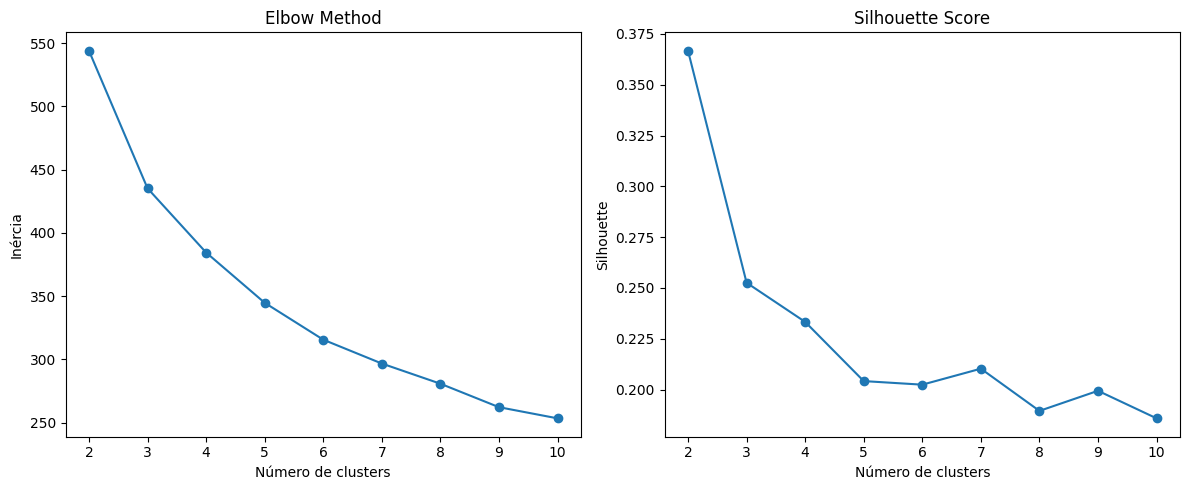

In [ ]:
# ==========================================
# BLOCO 3 — Elbow Method + Silhouette Score
# ==========================================

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

# normalização
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

inertia = []
silhouette_scores = []

k_range = range(2, 11)

for k in k_range:

    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)

    inertia.append(kmeans.inertia_)

    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)

print("====================================")
print("RESULTADOS")
print("====================================")

for k, iner, sil in zip(k_range, inertia, silhouette_scores):
    print(f"k={k}  |  inertia={iner:.2f}  |  silhouette={sil:.3f}")

# gráfico
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(k_range, inertia, marker='o')
plt.title("Elbow Method")
plt.xlabel("Número de clusters")
plt.ylabel("Inércia")

plt.subplot(1,2,2)
plt.plot(k_range, silhouette_scores, marker='o')
plt.title("Silhouette Score")
plt.xlabel("Número de clusters")
plt.ylabel("Silhouette")

plt.tight_layout()
plt.show()

In [ ]:
# ==========================================
# BLOCO 4 — Clusterização final (k = 3)
# ==========================================

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)

clusters = kmeans.fit_predict(X_scaled)

df["cluster"] = clusters

print("====================================")
print("DISTRIBUIÇÃO DOS CLUSTERS")
print("====================================")

print(df["cluster"].value_counts())

DISTRIBUIÇÃO DOS CLUSTERS
cluster
1    51
0    36
2    35
Name: count, dtype: int64


In [ ]:
# ==========================================
# BLOCO 5 — Perfil médio dos clusters
# ==========================================

perfil_clusters = df.groupby("cluster")[colunas_likert].mean()

print("====================================")
print("PERFIL MÉDIO DOS CLUSTERS")
print("====================================")

print(perfil_clusters.round(2))

print("\n====================================")
print("QUANTIDADE POR CLUSTER")
print("====================================")

print(df["cluster"].value_counts())

PERFIL MÉDIO DOS CLUSTERS
         1. Consigo explicar, em linhas gerais, a evolução da Inteligência Artificial até suas aplicações atuais na Educação.  \
cluster                                                                                                                         
0                                                     1.67                                                                      
1                                                     2.90                                                                      
2                                                     3.77                                                                      

         2. Identifico exemplos práticos de como a IA pode apoiar o processo de ensino-aprendizagem.  \
cluster                                                                                                
0                                                     2.25                                             
1               

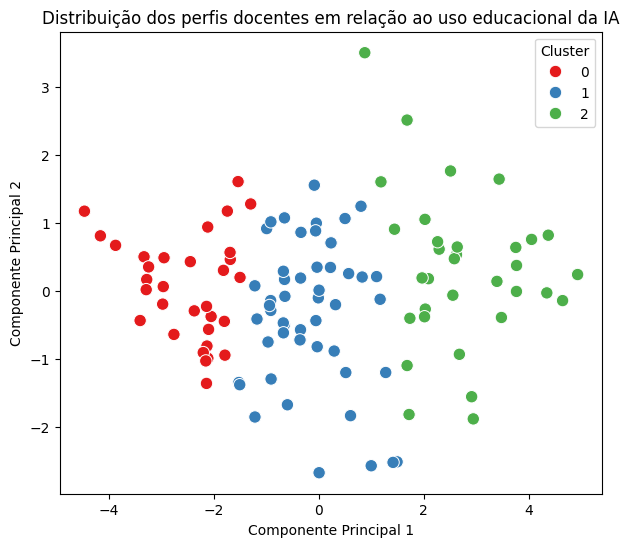

In [ ]:
# ==========================================
# BLOCO 6 — PCA para visualização dos clusters
# ==========================================

from sklearn.decomposition import PCA
import seaborn as sns

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

df["pca1"] = X_pca[:,0]
df["pca2"] = X_pca[:,1]

plt.figure(figsize=(7,6))

sns.scatterplot(
    x="pca1",
    y="pca2",
    hue="cluster",
    palette="Set1",
    data=df,
    s=80
)

plt.title("Distribuição dos perfis docentes em relação ao uso educacional da IA")
plt.xlabel("Componente Principal 1")
plt.ylabel("Componente Principal 2")

plt.legend(title="Cluster")

plt.show()

In [ ]:
# ==========================================
# BLOCO 7 — Tabela Disciplina × Cluster
# ==========================================

tabela_disciplina_cluster = pd.crosstab(
    df["Disciplina que leciona (principal)"],
    df["cluster"]
)

print("====================================")
print("DISCIPLINA x CLUSTER")
print("====================================")

print(tabela_disciplina_cluster)

DISCIPLINA x CLUSTER
cluster                             0   1  2
Disciplina que leciona (principal)          
Arte                                2   1  1
Biologia                            3   2  0
Ciências Naturais                   2   5  1
Filosofia                           0   1  2
Física                              2   2  2
Geografia                           2   4  3
História                            6   6  2
Língua Estrangeira Moderna          4   3  9
Língua Portuguesa                   4  10  4
Matemática                          8   5  6
Outros                              2   7  2
Química                             0   4  3
Sociologia                          1   1  0


In [ ]:
# ==========================================
# BLOCO 7A — Padronizar nome da disciplina
# ==========================================

print("Disciplinas únicas no dataset:")
print(sorted(df["Disciplina que leciona (principal)"].unique()))

Disciplinas únicas no dataset:
['Arte', 'Biologia', 'Ciências Naturais', 'Filosofia', 'Física', 'Geografia', 'História', 'Língua Estrangeira Moderna', 'Língua Portuguesa', 'Matemática', 'Outros', 'Química', 'Sociologia']


In [ ]:
# ==========================================
# BLOCO 7B — Ajustar nomes dos perfis (quebra de linha)
# ==========================================

df["perfil_ia"] = df["cluster"].map({
    0: "Aproximação Inicial\ncom IA",
    1: "Experimentação Pedagógica\ncom IA",
    2: "Integração Pedagógica\nda IA"
})

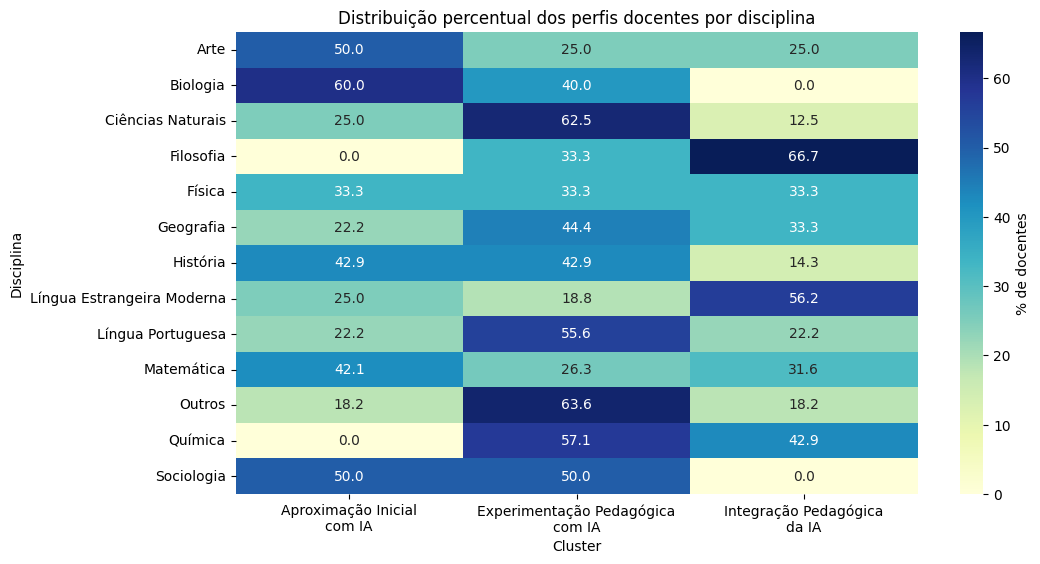

In [ ]:
# ==========================================
# BLOCO 8 — Heatmap Disciplina × Cluster (%)
# ==========================================

# tabela absoluta
tabela_disciplina_cluster = pd.crosstab(
    df["Disciplina que leciona (principal)"],
    df["perfil_ia"]
)

# converter para porcentagem por disciplina
tabela_percentual = tabela_disciplina_cluster.div(
    tabela_disciplina_cluster.sum(axis=1), axis=0
) * 100

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(11,6))

sns.heatmap(
    tabela_percentual,
    annot=True,
    fmt=".1f",
    cmap="YlGnBu",
    cbar_kws={'label': '% de docentes'}
)

plt.title("Distribuição percentual dos perfis docentes por disciplina")
plt.xlabel("Cluster")
plt.ylabel("Disciplina")

plt.show()

In [ ]:
# ==========================================
# BLOCO 9
# ==========================================

import pandas as pd
from sklearn.preprocessing import StandardScaler

df_pre = pd.read_excel("iii_ced_pre_teste.xlsx")
df_pos = pd.read_excel("iii_ced_pos_teste.xlsx")

df_pre.columns = df_pre.columns.str.strip()
df_pos.columns = df_pos.columns.str.strip()

id_col = "Nome Completo"

df_merge = pd.merge(df_pre, df_pos, on=id_col, suffixes=("_pre", "_pos"))

questoes = [
    "1. Consigo explicar, em linhas gerais, a evolução da Inteligência Artificial até suas aplicações atuais na Educação.",
    "2. Identifico exemplos práticos de como a IA pode apoiar o processo de ensino-aprendizagem.",
    "3. Sei apontar riscos éticos relevantes no uso de IA na Educação, como viés, privacidade e autoria.",
    "4. Tenho clareza sobre como orientar meus alunos para o uso responsável da IA em atividades escolares.",
    "5. Sei estruturar prompts que aumentam a qualidade e a utilidade das respostas de uma ferramenta de IA.",
    "6. Sou capaz de ajustar um prompt de acordo com o resultado obtido, refinando minhas solicitações.",
    "7. Consigo identificar atividades da minha disciplina que podem ser enriquecidas com o uso de IA generativa.",
    "8. Sei utilizar ferramentas de IA generativa para personalizar materiais educacionais conforme o perfil dos estudantes."
]

# scaler treinado no pré completo (122)
scaler = StandardScaler()
X_pre_scaled = scaler.fit_transform(df_pre[questoes])

# mesmos dados dos 32 pareados, mas convertidos para matriz
X_pre_32_scaled = scaler.transform(df_merge[[q + "_pre" for q in questoes]].to_numpy())
X_pos_32_scaled = scaler.transform(df_merge[[q + "_pos" for q in questoes]].to_numpy())

print("Pré completo:", X_pre_scaled.shape)
print("Pré pareado:", X_pre_32_scaled.shape)
print("Pós pareado:", X_pos_32_scaled.shape)

Pré completo: (122, 8)
Pré pareado: (32, 8)
Pós pareado: (32, 8)


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [ ]:
# ==================================================
# BLOCO 10 — clusters pré e pós com o modelo do pré
# ==================================================

from sklearn.cluster import KMeans

# modelo treinado no pré completo
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans.fit(X_pre_scaled)

# cluster pré dos 32 participantes pareados
df_merge["cluster_pre"] = kmeans.predict(X_pre_32_scaled)

# cluster pós desses mesmos 32, usando os mesmos centróides do pré
df_merge["cluster_pos"] = kmeans.predict(X_pos_32_scaled)

print(df_merge[[id_col, "cluster_pre", "cluster_pos"]].head())

  Nome Completo  cluster_pre  cluster_pos
0  professor_04            2            2
1  professor_06            1            1
2  professor_14            1            1
3  professor_22            1            2
4  professor_23            0            2


In [ ]:
# ==================================================
# BLOCO 10a
# ==================================================

cluster_labels = {
    0: "Aproximação Inicial\ncom IA",
    1: "Experimentação Pedagógica\ncom IA",
    2: "Integração Pedagógica\nda IA"
}

df_merge["perfil_pre"] = df_merge["cluster_pre"].map(cluster_labels)
df_merge["perfil_pos"] = df_merge["cluster_pos"].map(cluster_labels)

In [ ]:
# ==================================================
# BLOCO 11 — tabela de transição dos clusters
# ==================================================

transicao = pd.crosstab(
    df_merge["perfil_pre"],
    df_merge["perfil_pos"]
)

print(transicao)

perfil_pos                         Aproximação Inicial\ncom IA  \
perfil_pre                                                       
Aproximação Inicial\ncom IA                                  0   
Experimentação Pedagógica\ncom IA                            1   
Integração Pedagógica\nda IA                                 0   

perfil_pos                         Experimentação Pedagógica\ncom IA  \
perfil_pre                                                             
Aproximação Inicial\ncom IA                                        3   
Experimentação Pedagógica\ncom IA                                  4   
Integração Pedagógica\nda IA                                       0   

perfil_pos                         Integração Pedagógica\nda IA  
perfil_pre                                                       
Aproximação Inicial\ncom IA                                   5  
Experimentação Pedagógica\ncom IA                             9  
Integração Pedagógica\nda IA                

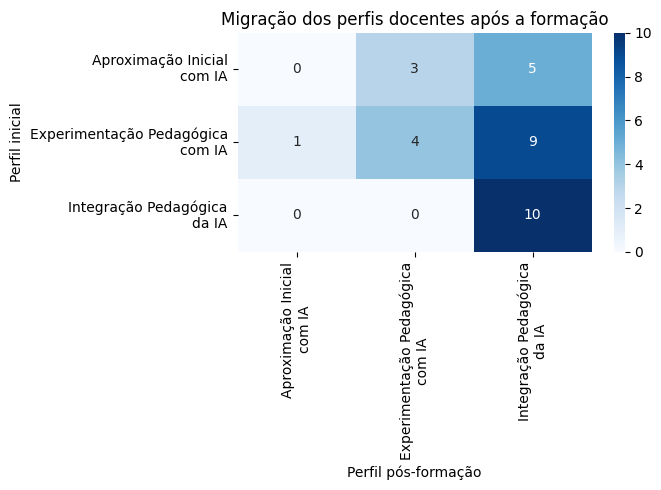

In [ ]:
# ==================================================
# BLOCO 11a — gráfico de transição dos clusters
# ==================================================

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))

sns.heatmap(
    transicao,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Migração dos perfis docentes após a formação")
plt.xlabel("Perfil pós-formação")
plt.ylabel("Perfil inicial")

plt.tight_layout()
plt.show()

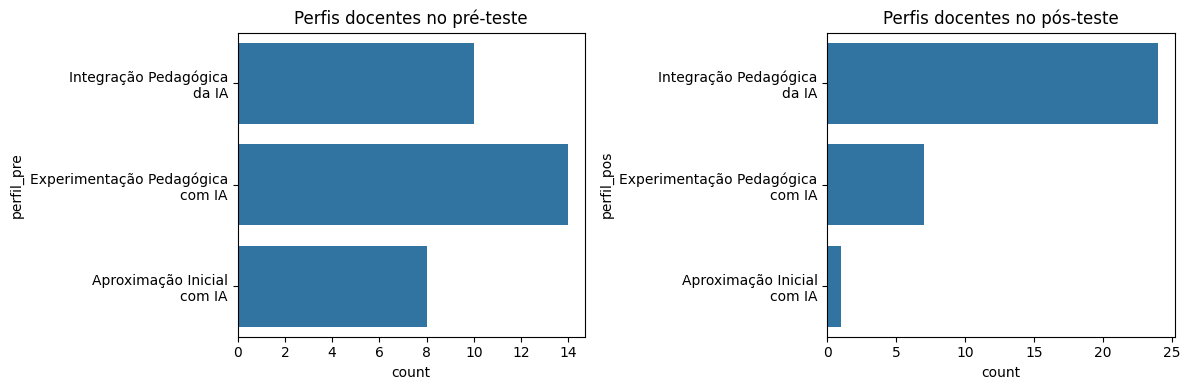

In [ ]:
# ==================================================
# BLOCO 12
# ==================================================

fig, axes = plt.subplots(1,2, figsize=(12,4))

sns.countplot(
    y=df_merge["perfil_pre"],
    ax=axes[0]
)

axes[0].set_title("Perfis docentes no pré-teste")

sns.countplot(
    y=df_merge["perfil_pos"],
    ax=axes[1]
)

axes[1].set_title("Perfis docentes no pós-teste")

plt.tight_layout()
plt.show()

/tmp/ipykernel_211/2335639717.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(
/tmp/ipykernel_211/2335639717.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


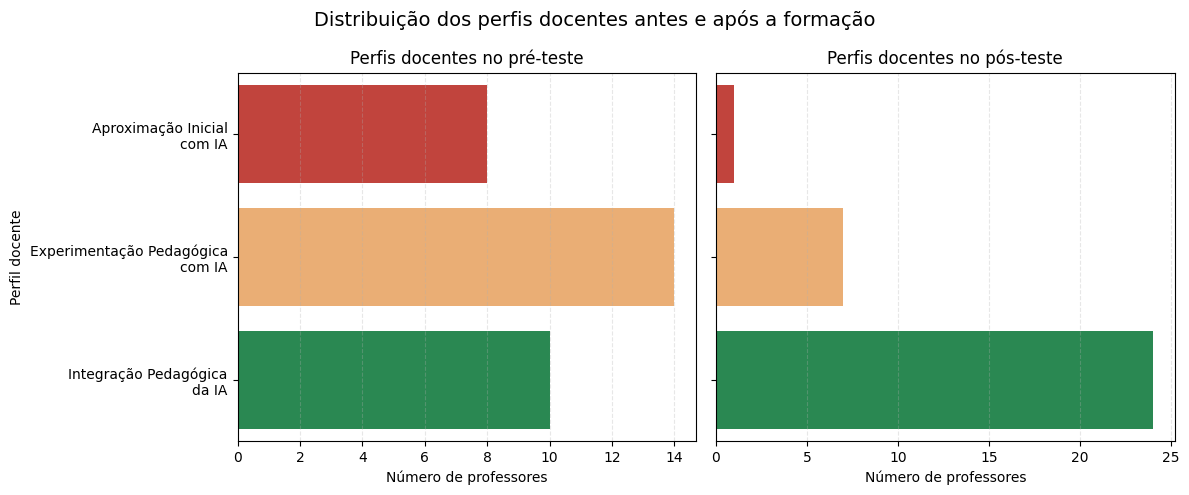

In [ ]:
# ==================================================
# BLOCO 12a
# ==================================================

import matplotlib.pyplot as plt
import seaborn as sns

ordem_perfis = [
    "Aproximação Inicial\ncom IA",
    "Experimentação Pedagógica\ncom IA",
    "Integração Pedagógica\nda IA"
]

cores = ["#d73027", "#fdae61", "#1a9850"]

fig, axes = plt.subplots(1, 2, figsize=(12,5), sharey=True)

sns.countplot(
    y=df_merge["perfil_pre"],
    order=ordem_perfis,
    palette=cores,
    ax=axes[0]
)

axes[0].set_title("Perfis docentes no pré-teste", fontsize=12)
axes[0].set_xlabel("Número de professores")
axes[0].set_ylabel("Perfil docente")
axes[0].grid(axis='x', linestyle='--', alpha=0.3)

sns.countplot(
    y=df_merge["perfil_pos"],
    order=ordem_perfis,
    palette=cores,
    ax=axes[1]
)

axes[1].set_title("Perfis docentes no pós-teste", fontsize=12)
axes[1].set_xlabel("Número de professores")
axes[1].set_ylabel("")
axes[1].grid(axis='x', linestyle='--', alpha=0.3)

plt.suptitle("Distribuição dos perfis docentes antes e após a formação", fontsize=14)

plt.tight_layout()
plt.show()

In [ ]:
# ==================================================
# BLOCO 12b
# ==================================================

centroides = pd.DataFrame(
    scaler.inverse_transform(kmeans.cluster_centers_),
    columns=questoes
)

centroides["media_geral"] = centroides.mean(axis=1)
print(centroides[["media_geral"]].sort_values("media_geral"))
print(centroides)

   media_geral
0     1.798611
1     2.830882
2     4.114286
   1. Consigo explicar, em linhas gerais, a evolução da Inteligência Artificial até suas aplicações atuais na Educação.  \
0                                           1.666667                                                                      
1                                           2.901961                                                                      
2                                           3.771429                                                                      

   2. Identifico exemplos práticos de como a IA pode apoiar o processo de ensino-aprendizagem.  \
0                                           2.250000                                             
1                                           3.470588                                             
2                                           4.114286                                             

   3. Sei apontar riscos éticos relevantes no uso de I

In [ ]:
# ==================================================
# BLOCO 12c
# ==================================================

pre_cols = [q + "_pre" for q in questoes]
pos_cols = [q + "_pos" for q in questoes]

df_merge["score_pre"] = df_merge[pre_cols].sum(axis=1)
df_merge["score_pos"] = df_merge[pos_cols].sum(axis=1)

df_merge["ganho_abs"] = df_merge["score_pos"] - df_merge["score_pre"]

df_merge[["score_pre","score_pos","ganho_abs"]].describe()

,score_pre,score_pos,ganho_abs
count,32.000000,32.00000,32.000000
mean,23.625000,30.25000,6.625000
std,7.028743,5.57066,6.173565
min,12.000000,16.00000,-5.000000
25%,18.000000,28.50000,1.000000
50%,22.000000,31.00000,7.000000
75%,29.250000,34.00000,11.000000
max,38.000000,40.00000,19.000000


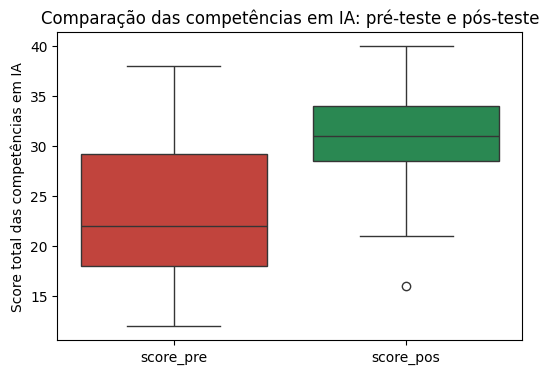

In [ ]:
# ==================================================
# BLOCO 12d
# ==================================================

plt.figure(figsize=(6,4))

sns.boxplot(
    data=df_merge[["score_pre","score_pos"]],
    palette=["#d73027","#1a9850"]
)

plt.ylabel("Score total das competências em IA")
plt.title("Comparação das competências em IA: pré-teste e pós-teste")

plt.show()

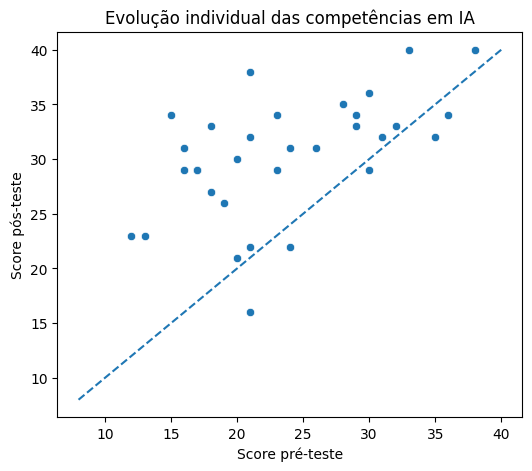

In [ ]:
# ==================================================
# BLOCO 12e
# ==================================================

plt.figure(figsize=(6,5))

sns.scatterplot(
    x=df_merge["score_pre"],
    y=df_merge["score_pos"]
)

plt.plot([8,40],[8,40], linestyle="--")

plt.xlabel("Score pré-teste")
plt.ylabel("Score pós-teste")
plt.title("Evolução individual das competências em IA")

plt.show()

In [ ]:
# ==================================================
# BLOCO 12f
# ==================================================

df_merge["ganho_norm"] = (
    (df_merge["score_pos"] - df_merge["score_pre"]) /
    (40 - df_merge["score_pre"])
)

df_merge["ganho_norm"].describe()

,ganho_norm
count,32.000000
mean,0.364939
std,0.385391
min,-0.600000
25%,0.121528
50%,0.423295
75%,0.587500
max,1.000000


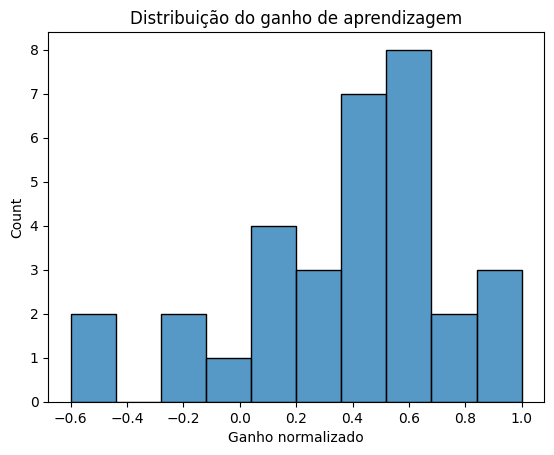

In [ ]:
# ==================================================
# BLOCO 12g
# ==================================================

sns.histplot(df_merge["ganho_norm"], bins=10)

plt.xlabel("Ganho normalizado")
plt.title("Distribuição do ganho de aprendizagem")

plt.show()

In [ ]:
# ==================================================
# BLOCO 12h
# ==================================================

from scipy.stats import wilcoxon

stat, p = wilcoxon(
    df_merge["score_pre"],
    df_merge["score_pos"]
)

print("Wilcoxon:", stat)
print("p-value:", p)

Wilcoxon: 38.0
p-value: 2.334681308140507e-05


/tmp/ipykernel_211/1526694333.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


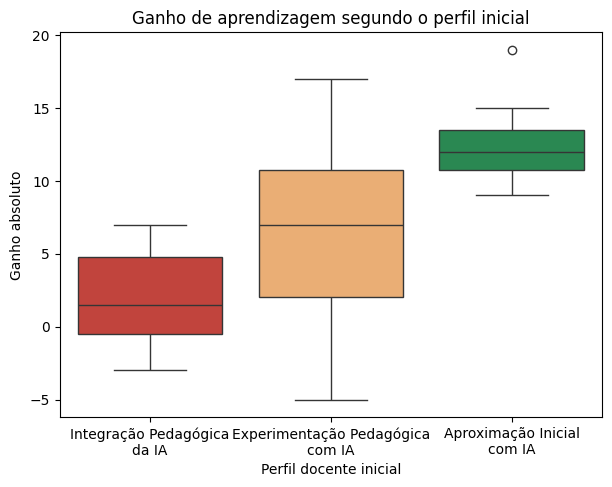

In [ ]:
# ==================================================
# BLOCO 12i
# ==================================================

plt.figure(figsize=(7,5))

sns.boxplot(
    x=df_merge["perfil_pre"],
    y=df_merge["ganho_abs"],
    palette=["#d73027","#fdae61","#1a9850"]
)

plt.xlabel("Perfil docente inicial")
plt.ylabel("Ganho absoluto")
plt.title("Ganho de aprendizagem segundo o perfil inicial")

plt.show()

In [ ]:
# ==================================================
# BLOCO 12j
# ==================================================
df_merge.columns.tolist()

['Carimbo de data/hora_pre',
 'Nome Completo',
 'Disciplina que leciona (principal)',
 'Ano Escolar (principal)',
 '1. Consigo explicar, em linhas gerais, a evolução da Inteligência Artificial até suas aplicações atuais na Educação._pre',
 '2. Identifico exemplos práticos de como a IA pode apoiar o processo de ensino-aprendizagem._pre',
 '3. Sei apontar riscos éticos relevantes no uso de IA na Educação, como viés, privacidade e autoria._pre',
 '4. Tenho clareza sobre como orientar meus alunos para o uso responsável da IA em atividades escolares._pre',
 '5. Sei estruturar prompts que aumentam a qualidade e a utilidade das respostas de uma ferramenta de IA._pre',
 '6. Sou capaz de ajustar um prompt de acordo com o resultado obtido, refinando minhas solicitações._pre',
 '7. Consigo identificar atividades da minha disciplina que podem ser enriquecidas com o uso de IA generativa._pre',
 '8. Sei utilizar ferramentas de IA generativa para personalizar materiais educacionais conforme o perfil 

In [ ]:
# ==================================================
# BLOCO 12k
# ==================================================
ux_cols = [c for c in df_merge.columns if c.startswith(("1. A estrutura",
                                                        "2. Os materiais",
                                                        "3. As palestras",
                                                        "4. A atuação",
                                                        "5. O ambiente"))]

df_merge["ux_score"] = df_merge[ux_cols].mean(axis=1)

df_merge["ux_score"].describe()

,ux_score
count,32.000000
mean,3.762500
std,0.997335
min,1.200000
25%,3.000000
50%,3.900000
75%,4.800000
max,5.000000


In [ ]:
# ==================================================
# BLOCO 12l
# ==================================================

from scipy.stats import spearmanr

corr, p = spearmanr(df_merge["ux_score"], df_merge["ganho_abs"])

print("Correlação Spearman:", corr)
print("p-value:", p)

Correlação Spearman: 0.5018467328855664
p-value: 0.0034283502067243236


In [ ]:
# ==================================================
# BLOCO 12m
# ==================================================

diff = df_merge["score_pos"] - df_merge["score_pre"]

mean_diff = diff.mean()
std_diff = diff.std(ddof=1)

cohen_d = mean_diff / std_diff

print("Média da diferença:", round(mean_diff,3))
print("Desvio padrão da diferença:", round(std_diff,3))
print("Cohen's d:", round(cohen_d,3))

Média da diferença: 6.625
Desvio padrão da diferença: 6.174
Cohen's d: 1.073


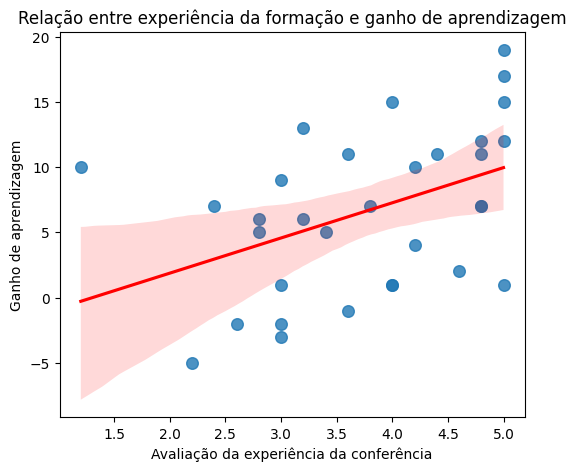

In [ ]:
# ==================================================
# BLOCO 12n
# ==================================================

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))

sns.regplot(
    x=df_merge["ux_score"],
    y=df_merge["ganho_abs"],
    scatter_kws={"s":70},
    line_kws={"color":"red"}
)

plt.xlabel("Avaliação da experiência da conferência")
plt.ylabel("Ganho de aprendizagem")
plt.title("Relação entre experiência da formação e ganho de aprendizagem")

plt.show()

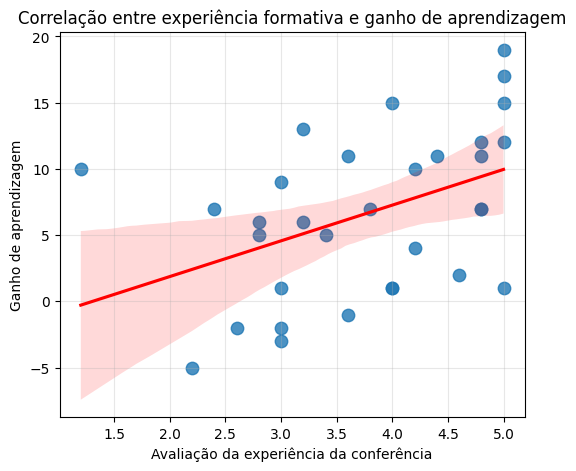

In [ ]:
# ==================================================
# BLOCO 12o
# ==================================================

plt.figure(figsize=(6,5))

sns.regplot(
    x=df_merge["ux_score"],
    y=df_merge["ganho_abs"],
    scatter_kws={"s":80, "alpha":0.8},
    line_kws={"color":"red"}
)

plt.xlabel("Avaliação da experiência da conferência")
plt.ylabel("Ganho de aprendizagem")
plt.title("Correlação entre experiência formativa e ganho de aprendizagem")

plt.grid(alpha=0.3)

plt.show()

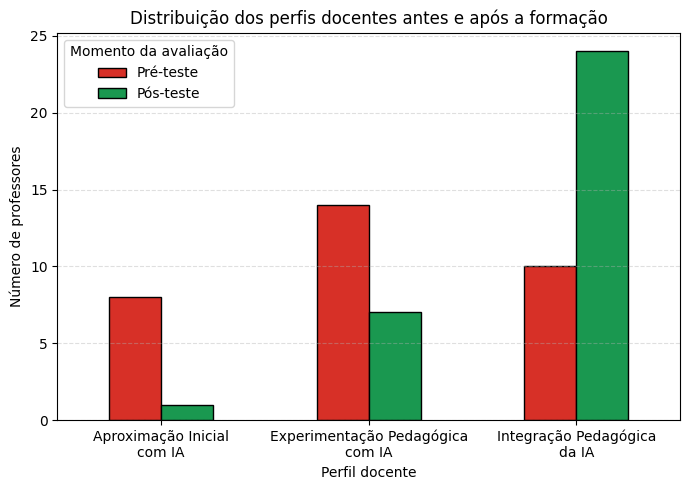

In [ ]:
# ==================================================
# BLOCO 12p
# ==================================================

import pandas as pd
import matplotlib.pyplot as plt

pre_counts = df_merge["perfil_pre"].value_counts()
pos_counts = df_merge["perfil_pos"].value_counts()

df_plot = pd.DataFrame({
    "Pré-teste": pre_counts,
    "Pós-teste": pos_counts
}).fillna(0)

df_plot = df_plot.loc[
    ["Aproximação Inicial\ncom IA",
     "Experimentação Pedagógica\ncom IA",
     "Integração Pedagógica\nda IA"]
]

ax = df_plot.plot(
    kind="bar",
    figsize=(7,5),
    color=["#d73027","#1a9850"],
    edgecolor="black"
)

plt.ylabel("Número de professores")
plt.xlabel("Perfil docente")
plt.title("Distribuição dos perfis docentes antes e após a formação")

plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.legend(title="Momento da avaliação")

plt.tight_layout()
plt.show()